IMPORT DATA

In [2]:
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download dataset dari Kaggle
path = kagglehub.dataset_download("mohadesehemamipour/online-retail-personalized-product-recommendation")
print("Path to dataset files:", path)

# Mencari file CSV di dalam direktori hasil download
csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    full_csv_path = csv_files[0]
    print(f"File CSV ditemukan: {full_csv_path}")
else:
    print("File CSV tidak ditemukan di direktori download.")

C:\Users\Nina Herlina\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Nina Herlina\.cache\kagglehub\datasets\mohadesehemamipour\online-retail-personalized-product-recommendation\versions\1
File CSV ditemukan: C:\Users\Nina Herlina\.cache\kagglehub\datasets\mohadesehemamipour\online-retail-personalized-product-recommendation\versions\1\online_retail_II.csv


LOAD DATA & DATA CLEANING

In [3]:
try:
    # Memuat dataset
    df = pd.read_csv(full_csv_path, encoding='latin1')
    print("Bentuk DataFrame asli:", df.shape)

    # 1. Hapus baris dengan 'Customer ID' yang kosong (NaN)
    df_cleaned = df.dropna(subset=['Customer ID']).copy()

    # 2. Hapus transaksi pembatalan (Invoice diawali huruf 'C')
    df_cleaned['Invoice'] = df_cleaned['Invoice'].astype(str)
    df_cleaned = df_cleaned[~df_cleaned['Invoice'].str.startswith('C', na=False)]

    # 3. Hapus transaksi dengan Quantity atau Price <= 0
    df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]

    # 4. Konversi InvoiceDate ke datetime dan hapus NaT
    df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'], errors='coerce')
    df_cleaned.dropna(subset=['InvoiceDate'], inplace=True)

    # 5. Hapus duplikat transaksi
    initial_rows_dup = df_cleaned.shape[0]
    df_cleaned.drop_duplicates(inplace=True)
    final_rows_dup = df_cleaned.shape[0]
    print(f"Jumlah baris duplikat yang dihapus: {initial_rows_dup - final_rows_dup}")

    # Simpan ke variabel global
    df_retail_cleaned = df_cleaned.copy()
    print("\nBentuk DataFrame setelah pembersihan:", df_retail_cleaned.shape)

except Exception as e:
    print(f"Terjadi kesalahan saat memuat data: {e}")

Bentuk DataFrame asli: (525461, 8)
Jumlah baris duplikat yang dihapus: 6748

Bentuk DataFrame setelah pembersihan: (400916, 8)


FEATURE ENGINEERING - Agregasi RFM Metrics

In [4]:
if 'df_retail_cleaned' in locals():
    # 1. Tentukan Cutoff Date
    cutoff_date = df_retail_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)
    print(f"Cutoff Date untuk perhitungan RFM: {cutoff_date}")

    # 2. Hitung TotalPrice
    df_retail_cleaned['TotalPrice'] = df_retail_cleaned['Quantity'] * df_retail_cleaned['Price']

    # 3. Hitung RFM Metrics per Customer
    rfm_df = df_retail_cleaned.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda date: (cutoff_date - date.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('TotalPrice', 'sum')
    ).reset_index()

    print("\nHead RFM Metrics:")
    print(rfm_df.head())
else:
    print("Error: df_retail_cleaned tidak ditemukan.")

Cutoff Date untuk perhitungan RFM: 2010-12-10 20:01:00

Head RFM Metrics:
   Customer ID  Recency  Frequency  Monetary
0      12346.0      165         11    372.86
1      12347.0        3          2   1323.32
2      12348.0       74          1    222.16
3      12349.0       43          3   2671.14
4      12351.0       11          1    300.93


FEATURE ENGINEERING - Pelabelan Target (Churn) & Fitur Pendukung

In [5]:
if 'rfm_df' in locals() and 'df_retail_cleaned' in locals():
    # 1. Label Churn (Recency > 90 hari)
    rfm_df['Churn'] = (rfm_df['Recency'] > 90).astype(int)

    # 2. Rata-rata Nilai Transaksi (AOV)
    rfm_df['AOV'] = rfm_df['Monetary'] / rfm_df['Frequency']

    # 3. Rentang Waktu Aktif (Tenure)
    tenure_df = df_retail_cleaned.groupby('Customer ID').agg(
        FirstPurchase=('InvoiceDate', 'min'),
        LastPurchase=('InvoiceDate', 'max')
    ).reset_index()
    tenure_df['Tenure'] = (tenure_df['LastPurchase'] - tenure_df['FirstPurchase']).dt.days

    rfm_df = pd.merge(rfm_df, tenure_df[['Customer ID', 'Tenure']], on='Customer ID', how='left')

    # 4. Variasi Kategori Barang (ProductVariety)
    product_variety_df = df_retail_cleaned.groupby('Customer ID')['Description'].nunique().reset_index()
    product_variety_df.rename(columns={'Description': 'ProductVariety'}, inplace=True)

    rfm_df = pd.merge(rfm_df, product_variety_df, on='Customer ID', how='left')

    print("\nDataFrame Akhir Siap Analisis:")
    print(rfm_df.head())
    print("\nDistribusi Churn:")
    print(rfm_df['Churn'].value_counts())
else:
    print("Error: Dataframe pendukung tidak ditemukan.")


DataFrame Akhir Siap Analisis:
   Customer ID  Recency  Frequency  Monetary  Churn         AOV  Tenure  \
0      12346.0      165         11    372.86      1   33.896364     196   
1      12347.0        3          2   1323.32      0  661.660000      37   
2      12348.0       74          1    222.16      0  222.160000       0   
3      12349.0       43          3   2671.14      0  890.380000     181   
4      12351.0       11          1    300.93      0  300.930000       0   

   ProductVariety  
0              25  
1              70  
2              20  
3              94  
4              21  

Distribusi Churn:
Churn
0    2877
1    1435
Name: count, dtype: int64


--- Ringkasan Statistik Fitur Numerik ---
           Recency    Frequency       Monetary           AOV       Tenure  \
count  4312.000000  4312.000000    4312.000000   4312.000000  4312.000000   
mean     91.171846     4.455705    2040.406712    376.373364   133.998609   
std      96.860633     8.170213    8911.755977    492.357455   132.827183   
min       1.000000     1.000000       2.950000      2.950000     0.000000   
25%      18.000000     1.000000     307.187500    179.490000     0.000000   
50%      53.000000     2.000000     701.615000    285.048333   105.000000   
75%     136.000000     5.000000    1714.932500    421.483750   254.000000   
max     374.000000   205.000000  349164.350000  11880.840000   373.000000   

       ProductVariety  
count     4312.000000  
mean        65.066327  
std         89.251660  
min          1.000000  
25%         17.000000  
50%         38.000000  
75%         81.000000  
max       1862.000000  


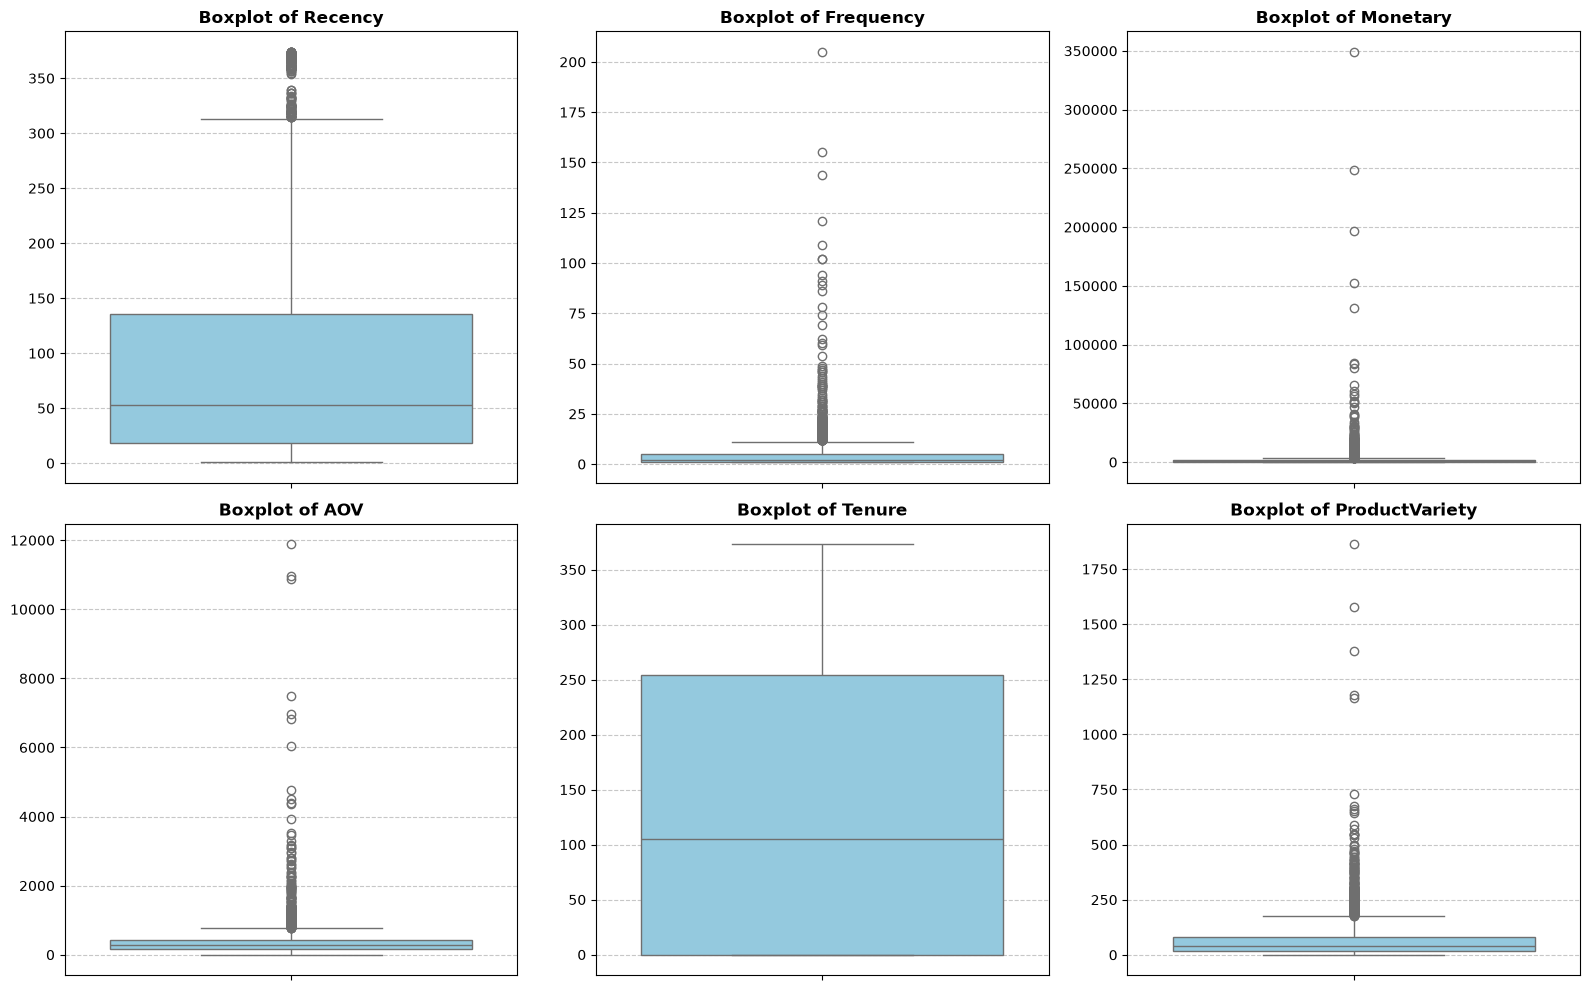

In [6]:
# Menampilkan Ringkasan Statistik
print("--- Ringkasan Statistik Fitur Numerik ---")
print(rfm_df[['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'ProductVariety']].describe())

# Visualisasi Boxplot untuk Cek Outlier
features = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'ProductVariety']

plt.figure(figsize=(16, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=rfm_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

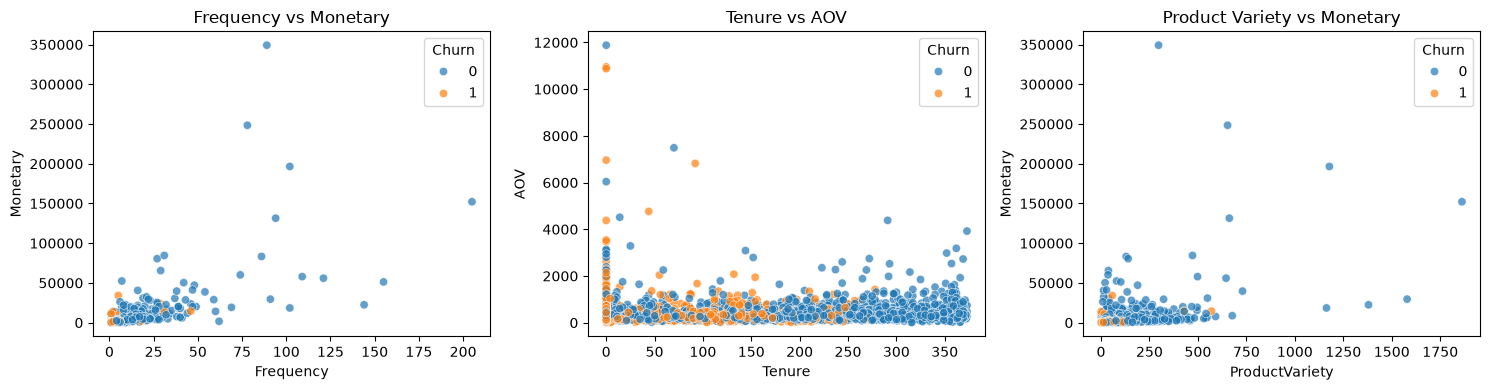

Persentase outlier pada kolom Frequency: 6.61% (285 baris)
Persentase outlier pada kolom Monetary: 9.81% (423 baris)
Persentase outlier pada kolom AOV: 6.93% (299 baris)
Persentase outlier pada kolom ProductVariety: 7.28% (314 baris)


In [7]:
# Visualisasi Sebaran Fitur vs Churn
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='Churn', alpha=0.7)
plt.title('Frequency vs Monetary')

plt.subplot(1, 3, 2)
sns.scatterplot(data=rfm_df, x='Tenure', y='AOV', hue='Churn', alpha=0.7)
plt.title('Tenure vs AOV')

plt.subplot(1, 3, 3)
sns.scatterplot(data=rfm_df, x='ProductVariety', y='Monetary', hue='Churn', alpha=0.7)
plt.title('Product Variety vs Monetary')

plt.tight_layout()
plt.show()

# Menghitung Persentase Outlier berdasarkan kriteria IQR
for col in ['Frequency', 'Monetary', 'AOV', 'ProductVariety']:
    Q1 = rfm_df[col].quantile(0.25)
    Q3 = rfm_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = rfm_df[(rfm_df[col] < (Q1 - 1.5 * IQR)) | (rfm_df[col] > (Q3 + 1.5 * IQR))]
    percentage = (len(outliers) / len(rfm_df)) * 100
    print(f"Persentase outlier pada kolom {col}: {percentage:.2f}% ({len(outliers)} baris)")

PENANGANAN OULIER

In [8]:
# Salin dataframe agar data asli tetap tersimpan
rfm_capped = rfm_df.copy()

# Daftar kolom numerik yang akan ditangani outlier-nya
features_to_cap = ['Frequency', 'Monetary', 'AOV', 'ProductVariety']

for col in features_to_cap:
    Q1 = rfm_capped[col].quantile(0.25)
    Q3 = rfm_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Terapkan Capping
    rfm_capped[col] = np.where(
        rfm_capped[col] > upper_bound, 
        upper_bound,
        np.where(
            rfm_capped[col] < lower_bound, 
            lower_bound, 
            rfm_capped[col]
        )
    )

print("--- Hasil Setelah IQR Capping ---")
print(rfm_capped[['Frequency', 'Monetary', 'AOV', 'ProductVariety']].describe())

--- Hasil Setelah IQR Capping ---
         Frequency     Monetary          AOV  ProductVariety
count  4312.000000  4312.000000  4312.000000     4312.000000
mean      3.602505  1200.294114   327.636683       56.731215
std       3.080784  1186.606884   197.940707       52.160596
min       1.000000     2.950000     2.950000        1.000000
25%       1.000000   307.187500   179.490000       17.000000
50%       2.000000   701.615000   285.048333       38.000000
75%       5.000000  1714.932500   421.483750       81.000000
max      11.000000  3826.550000   784.474375      177.000000


In [9]:
# Salin dataframe
rfm_log = rfm_df.copy()

# Fitur yang akan ditransformasi log
features_to_transform = ['Recency', 'Frequency', 'Monetary', 'AOV', 'ProductVariety']

for col in features_to_transform:
    # Menggunakan log1p untuk menghindari error log(0) jika ada nilai 0
    rfm_log[f'{col}_log'] = np.log1p(rfm_log[col])

print("--- Kolom Baru Hasil Transformasi Log ---")
print(rfm_log[[f'{col}_log' for col in features_to_transform]].head())

--- Kolom Baru Hasil Transformasi Log ---
   Recency_log  Frequency_log  Monetary_log   AOV_log  ProductVariety_log
0     5.111988       2.484907      5.923881  3.552383            3.258097
1     1.386294       1.098612      7.188654  6.496262            4.262680
2     4.317488       0.693147      5.407889  5.407889            3.044522
3     3.784190       1.386294      7.890635  6.792771            4.553877
4     2.484907       0.693147      5.710195  5.710195            3.091042


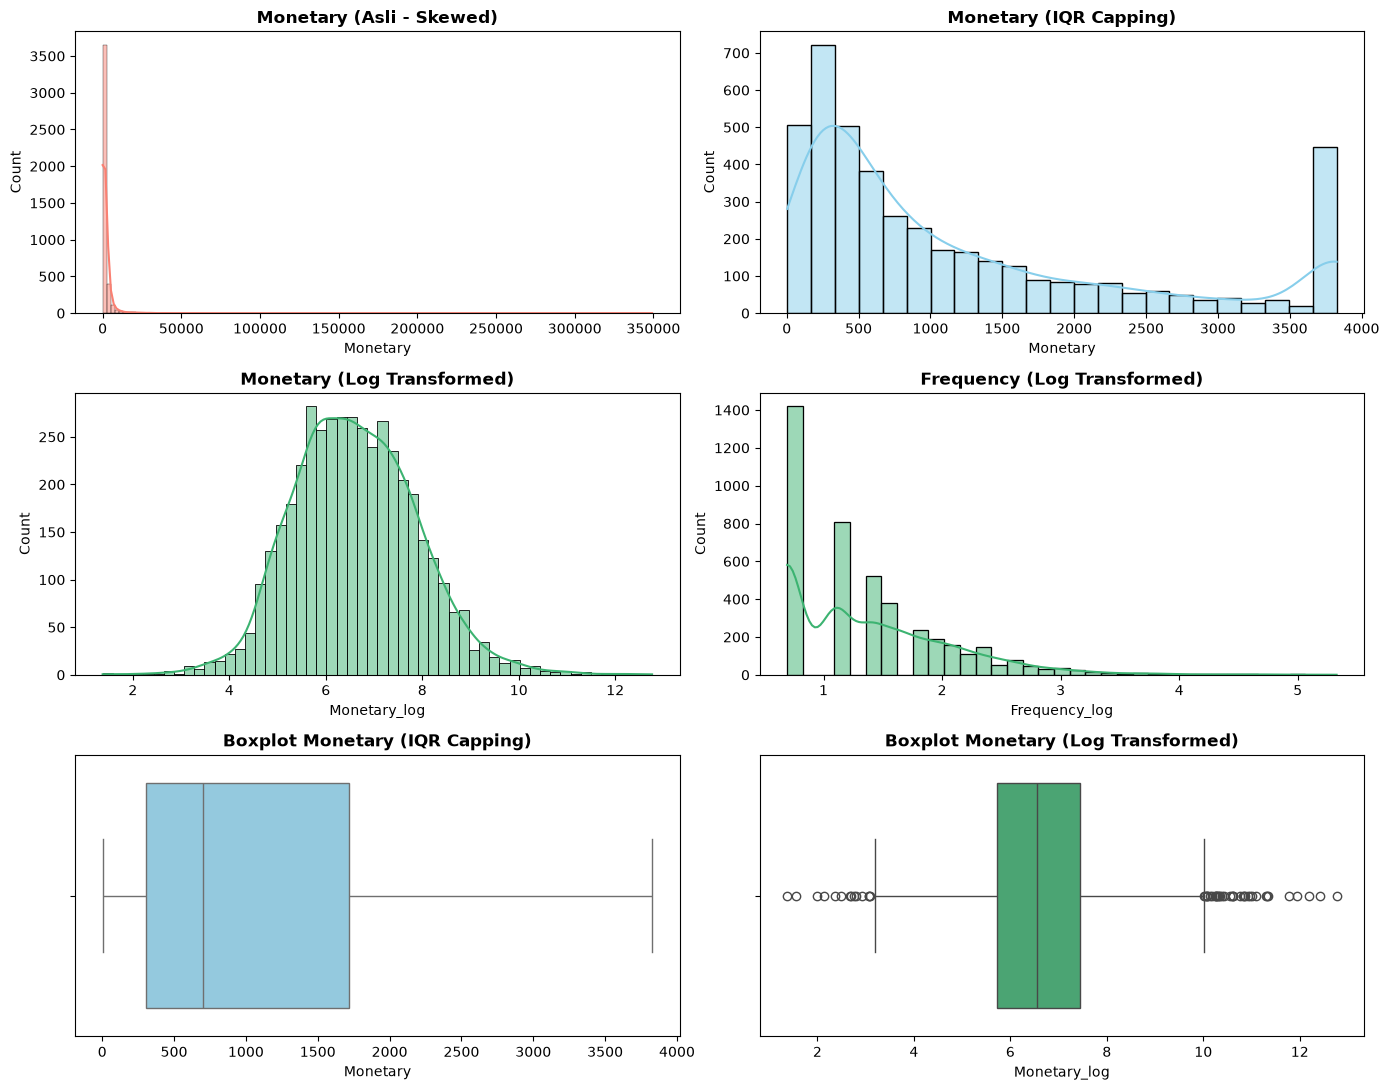

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))

# Row 1: Data Asli vs IQR Capping (Monetary)
sns.histplot(rfm_df['Monetary'], kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Monetary (Asli - Skewed)', fontweight='bold')

sns.histplot(rfm_capped['Monetary'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Monetary (IQR Capping)', fontweight='bold')

# Row 2: Log Transformation (Monetary & Frequency)
sns.histplot(rfm_log['Monetary_log'], kde=True, ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Monetary (Log Transformed)', fontweight='bold')

sns.histplot(rfm_log['Frequency_log'], kde=True, ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title('Frequency (Log Transformed)', fontweight='bold')

# Row 3: Boxplot Perbandingan
sns.boxplot(x=rfm_capped['Monetary'], ax=axes[2, 0], color='skyblue')
axes[2, 0].set_title('Boxplot Monetary (IQR Capping)', fontweight='bold')

sns.boxplot(x=rfm_log['Monetary_log'], ax=axes[2, 1], color='mediumseagreen')
axes[2, 1].set_title('Boxplot Monetary (Log Transformed)', fontweight='bold')

plt.tight_layout()
plt.show()

Observation & Performance Window

In [11]:
# Pastikan df_retail_cleaned tersedia dari sel sebelumnya
if 'df_retail_cleaned' in locals():
    print("--- Menyiapkan Data dengan Observation & Performance Window ---")

    # 1. Tentukan Titik Potong Timeline (Cutoff Dates)
    max_date = df_retail_cleaned['InvoiceDate'].max()
    
    # Performance Window: 90 hari terakhir
    obs_end_date = max_date - pd.Timedelta(days=90)
    
    print(f"Tanggal Awal Dataset     : {df_retail_cleaned['InvoiceDate'].min()}")
    print(f"Akhir Periode Observasi  : {obs_end_date}")
    print(f"Akhir Periode Kinerja    : {max_date}")

    # 2. Filter Data untuk Observation Window (Data Histori untuk Feature Engineering)
    df_obs = df_retail_cleaned[df_retail_cleaned['InvoiceDate'] <= obs_end_date].copy()

    # 3. Feature Engineering pada Observation Window
    df_obs['TotalPrice'] = df_obs['Quantity'] * df_obs['Price']
    
    # Fitur Cutoff Date internal untuk perhitungan Recency dalam masa observasi
    obs_cutoff = obs_end_date + pd.Timedelta(days=1)

    rfm_obs = df_obs.groupby('Customer ID').agg(
        Recency=('InvoiceDate', lambda date: (obs_cutoff - date.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('TotalPrice', 'sum')
    ).reset_index()

    # Fitur Tambahan (AOV, Tenure, Product Variety) dari masa observasi
    rfm_obs['AOV'] = rfm_obs['Monetary'] / rfm_obs['Frequency']

    tenure_df = df_obs.groupby('Customer ID').agg(
        FirstPurchase=('InvoiceDate', 'min'),
        LastPurchase=('InvoiceDate', 'max')
    ).reset_index()
    rfm_obs['Tenure'] = (tenure_df['LastPurchase'] - tenure_df['FirstPurchase']).dt.days

    variety_df = df_obs.groupby('Customer ID')['Description'].nunique().reset_index()
    variety_df.rename(columns={'Description': 'ProductVariety'}, inplace=True)
    rfm_obs = pd.merge(rfm_obs, variety_df, on='Customer ID', how='left')

    # 4. Tentukan Label Churn berdasarkan Performance Window (3 Bulan Terakhir)
    # Pelanggan aktif di periode observasi yang TIDAK bertransaksi di periode kinerja = Churn (1)
    df_perf = df_retail_cleaned[df_retail_cleaned['InvoiceDate'] > obs_end_date]
    active_in_perf = df_perf['Customer ID'].unique()

    # Buat target label Churn
    rfm_obs['Churn'] = rfm_obs['Customer ID'].apply(lambda x: 0 if x in active_in_perf else 1)

    # Simpan ke dataframe baru untuk pemodelan
    rfm_windowed = rfm_obs.copy()

    print("\n--- Data Frame Baru Berhasil Dibuat (rfm_windowed) ---")
    print(rfm_windowed.head())
    print("\nDistribusi Label Churn:")
    print(rfm_windowed['Churn'].value_counts(normalize=True))

else:
    print("Error: df_retail_cleaned tidak ditemukan.")

--- Menyiapkan Data dengan Observation & Performance Window ---
Tanggal Awal Dataset     : 2009-12-01 07:45:00
Akhir Periode Observasi  : 2010-09-10 20:01:00
Akhir Periode Kinerja    : 2010-12-09 20:01:00

--- Data Frame Baru Berhasil Dibuat (rfm_windowed) ---
   Customer ID  Recency  Frequency  Monetary         AOV  Tenure  \
0      12346.0       75         11    372.86   33.896364     196   
1      12349.0      116          2   1268.52  634.260000      18   
2      12355.0      113          1    488.21  488.210000       0   
3      12358.0       96          2   1697.93  848.965000     181   
4      12359.0       81          5   2012.03  402.406000     198   

   ProductVariety  Churn  
0              25      1  
1              47      0  
2              22      1  
3              34      0  
4              83      0  

Distribusi Label Churn:
Churn
0    0.575067
1    0.424933
Name: proportion, dtype: float64


--- Hasil Evaluasi Model Baru (tanpa Data Leakage) ---
ROC-AUC Score : 0.7136
Precision     : 0.5952
Recall        : 0.6864


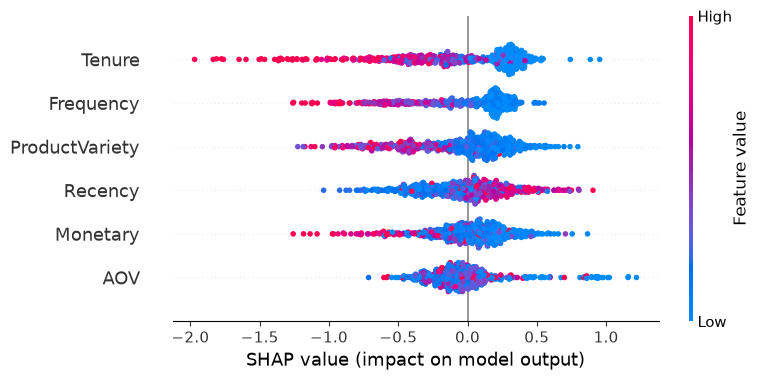

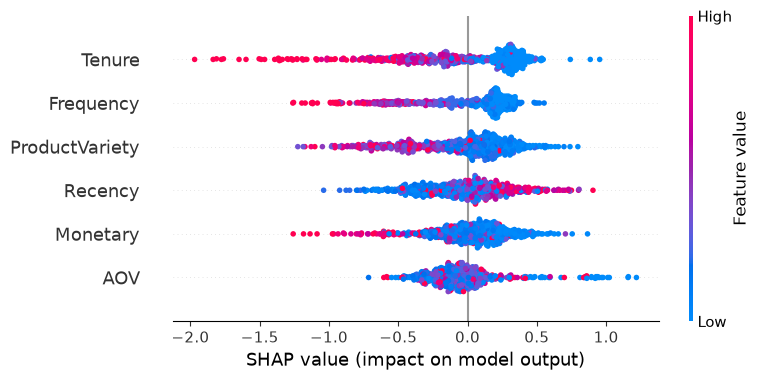

In [12]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import shap
import matplotlib.pyplot as plt

if 'rfm_windowed' in locals():
    # 1. Penyiapan Fitur & Target (Recency sekarang AMAN digunakan karena dihitung di masa lalu)
    X = rfm_windowed.drop(columns=['Customer ID', 'Churn']).fillna(0)
    y = rfm_windowed['Churn']

    # 2. Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 3. Train Model
    neg_count, pos_count = y_train.value_counts()[0], y_train.value_counts()[1]
    model_v2 = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        scale_pos_weight=neg_count / pos_count
    )
    model_v2.fit(X_train, y_train)

    # 4. Evaluasi
    y_pred_proba = model_v2.predict_proba(X_test)[:, 1]
    y_pred = model_v2.predict(X_test)

    print("--- Hasil Evaluasi Model Baru (tanpa Data Leakage) ---")
    print(f"ROC-AUC Score : {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"Precision     : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall        : {recall_score(y_test, y_pred):.4f}")

    # 5. Visualisasi SHAP Values Baru
    explainer = shap.TreeExplainer(model_v2)
    shap_values = explainer.shap_values(X_test)

    plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_values, X_test)
    # 1. Hitung SHAP Values
    explainer = shap.TreeExplainer(model_v2)
    shap_values = explainer.shap_values(X_test)
    # 2. Render SHAP Summary Plot secara langsung (Tanpa plt.figure tambahan)
    shap.summary_plot(shap_values, X_test)
    plt.show()

else:
    print("Error: rfm_windowed belum tersedia.")

MODELING - Customer Lifetime Value / CLTV

--- Memulai Model 2: Customer Lifetime Value (CLTV) ---
Ringkasan Data Lifetimes (5 Baris Pertama):
             frequency  recency      T  monetary_value
Customer ID                                           
12346.0            6.0    196.0  270.0       47.143333
12349.0            1.0     19.0  134.0      200.000000
12355.0            0.0      0.0  112.0        0.000000
12358.0            1.0    181.0  276.0      268.100000
12359.0            4.0    199.0  279.0      312.835000

[1/2] Fitting BG/NBD Model...
[2/2] Fitting Gamma-Gamma Model...

--- Hasil Prediksi CLTV Pelanggan ---
             frequency  monetary_value  predicted_purchases  \
Customer ID                                                   
12346.0            6.0       47.143333             3.628443   
12349.0            1.0      200.000000             1.495996   
12355.0            0.0        0.000000             0.745530   
12358.0            1.0      268.100000             0.898594   
12359.0            4.0      312.

C:\Users\Nina Herlina\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


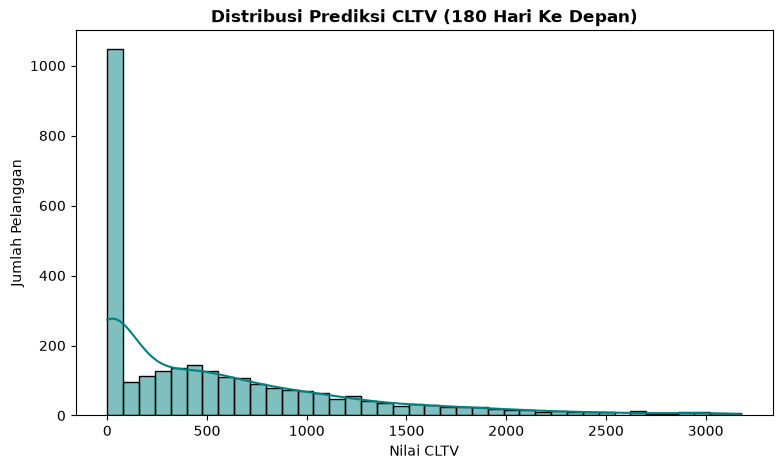

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Pastikan df_obs (data periode observasi) dari langkah sebelumnya sudah ada
if 'df_obs' in locals() and 'obs_end_date' in locals():
    print("--- Memulai Model 2: Customer Lifetime Value (CLTV) ---")

    # 1. Transformasi Data Histori Observasi untuk Lifetimes
    rfm_lifetimes = summary_data_from_transaction_data(
        df_obs,
        customer_id_col='Customer ID',
        datetime_col='InvoiceDate',
        monetary_value_col='TotalPrice',
        observation_period_end=obs_end_date
    )

    print("Ringkasan Data Lifetimes (5 Baris Pertama):")
    print(rfm_lifetimes.head())

    # 2. Fit Model BG/NBD (Memprediksi Frekuensi Transaksi Masa Depan)
    print("\n[1/2] Fitting BG/NBD Model...")
    bgf = BetaGeoFitter(penalizer_coef=0.01)
    bgf.fit(rfm_lifetimes['frequency'], rfm_lifetimes['recency'], rfm_lifetimes['T'])

    # 3. Fit Model Gamma-Gamma (Memprediksi Rata-rata Nilai Transaksi Masa Depan)
    # Model Gamma-Gamma hanya valid untuk pelanggan dengan setidaknya 1 kali repeat order (frequency > 0)
    print("[2/2] Fitting Gamma-Gamma Model...")
    rfm_lifetimes_repeat = rfm_lifetimes[rfm_lifetimes['frequency'] > 0].copy()

    ggf = GammaGammaFitter(penalizer_coef=0.01)
    ggf.fit(rfm_lifetimes_repeat['frequency'], rfm_lifetimes_repeat['monetary_value'])

    # 4. Prediksi CLTV untuk 180 Hari Ke Depan (6 Bulan)
    days_to_predict = 180

    # Prediksi jumlah transaksi di masa depan
    rfm_lifetimes['predicted_purchases'] = bgf.predict(
        days_to_predict, 
        rfm_lifetimes['frequency'], 
        rfm_lifetimes['recency'], 
        rfm_lifetimes['T']
    )

    # Prediksi rata-rata monetary value
    rfm_lifetimes['predicted_monetary'] = ggf.conditional_expected_average_profit(
        rfm_lifetimes['frequency'], 
        rfm_lifetimes['monetary_value']
    )
    
    # Pelanggan dengan frequency == 0 harus diisi 0 secara eksplisit
    rfm_lifetimes.loc[rfm_lifetimes['frequency'] == 0, 'predicted_monetary'] = 0

    # Hitung Estimasi Nilai CLTV
    rfm_lifetimes['CLTV_180_days'] = rfm_lifetimes['predicted_purchases'] * rfm_lifetimes['predicted_monetary']

    print("\n--- Hasil Prediksi CLTV Pelanggan ---")
    print(rfm_lifetimes[['frequency', 'monetary_value', 'predicted_purchases', 'predicted_monetary', 'CLTV_180_days']].head())

    # 5. Visualisasi Distribusi CLTV
    plt.figure(figsize=(9, 5))
    # Filter 95% kuantil terbawah agar nilai outlier tidak merusak grafik
    limit_95 = rfm_lifetimes['CLTV_180_days'].quantile(0.95)
    sns.histplot(rfm_lifetimes[rfm_lifetimes['CLTV_180_days'] < limit_95]['CLTV_180_days'], bins=40, kde=True, color='teal')
    
    plt.title(f'Distribusi Prediksi CLTV ({days_to_predict} Hari Ke Depan)', fontsize=12, fontweight='bold')
    plt.xlabel('Nilai CLTV')
    plt.ylabel('Jumlah Pelanggan')
    plt.show()

else:
    print("Error: df_obs atau obs_end_date tidak ditemukan. Pastikan sel persiapan data windowed sudah dijalankan.")

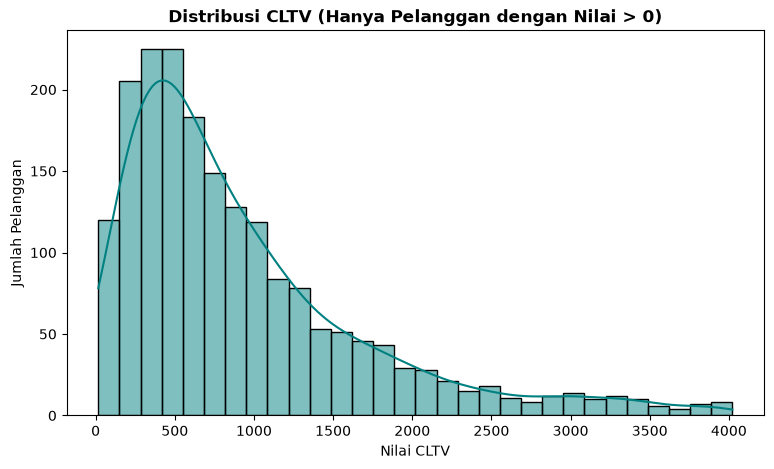

In [14]:
# Filter hanya pelanggan yang diprediksi memiliki CLTV > 0
cltv_active = rfm_lifetimes[rfm_lifetimes['CLTV_180_days'] > 0]

plt.figure(figsize=(9, 5))
limit_95 = cltv_active['CLTV_180_days'].quantile(0.95)

sns.histplot(cltv_active[cltv_active['CLTV_180_days'] < limit_95]['CLTV_180_days'], bins=30, kde=True, color='teal')
plt.title('Distribusi CLTV (Hanya Pelanggan dengan Nilai > 0)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai CLTV')
plt.ylabel('Jumlah Pelanggan')
plt.show()

In [15]:
# 1. Salin data dasar
df_final_output = rfm_windowed[['Customer ID', 'Churn']].copy()


# 2. Prediksi probabilitas churn untuk seluruh dataset
df_final_output['Churn_Probability'] = model_v2.predict_proba(X)[:, 1]

# 3. Kategori Risiko Churn
df_final_output['Churn_Risk'] = pd.cut(
    df_final_output['Churn_Probability'], 
    bins=[-1, 0.4, 0.7, 1.0], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# 4. Ekstrak Country dan Top Product dari data mentah (df_raw / df_cleaned)
# Pastikan 'df' di bawah ini diganti dengan nama DataFrame mentah transaksi kamu
customer_country = df.groupby('Customer ID')['Country'].first().reset_index()

customer_top_product = (
    df.groupby(['Customer ID', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Customer ID', 'Quantity'], ascending=[True, False])
    .groupby('Customer ID')
    .first()
    .reset_index()[['Customer ID', 'Description']]
    .rename(columns={'Description': 'Top_Product'})
)

# 5. Siapkan rfm_lifetimes untuk di-merge
rfm_lifetimes_temp = rfm_lifetimes.reset_index().copy()

# SAMAKAN TIPE DATA ke String (Mencegah mismatch / NaN saat merge)
df_final_output['Customer ID'] = df_final_output['Customer ID'].astype(str)
rfm_lifetimes_temp['Customer ID'] = rfm_lifetimes_temp['Customer ID'].astype(str)
customer_country['Customer ID'] = customer_country['Customer ID'].astype(str)
customer_top_product['Customer ID'] = customer_top_product['Customer ID'].astype(str)

# 6. Gabungkan Data Churn, CLTV, Country, dan Top Product
df_final_output = df_final_output.merge(
    rfm_lifetimes_temp[['Customer ID', 'CLTV_180_days', 'predicted_purchases']], 
    on='Customer ID', 
    how='left'
)

df_final_output = df_final_output.merge(customer_country, on='Customer ID', how='left')
df_final_output = df_final_output.merge(customer_top_product, on='Customer ID', how='left')

# 7. Isi nilai NaN/kosong
df_final_output['CLTV_180_days'] = df_final_output['CLTV_180_days'].fillna(0)
df_final_output['predicted_purchases'] = df_final_output['predicted_purchases'].fillna(0)
df_final_output['Country'] = df_final_output['Country'].fillna('Unknown')
df_final_output['Top_Product'] = df_final_output['Top_Product'].fillna('No Product History')

# 8. Ekspor ke CSV
df_final_output.to_csv('churn_clv_predictions.csv', index=False)

print("--- Ekspor Berhasil! ---")
print(df_final_output.head())

--- Ekspor Berhasil! ---
  Customer ID  Churn  Churn_Probability   Churn_Risk  CLTV_180_days  \
0     12346.0      1           0.829253    High Risk     178.485462   
1     12349.0      0           0.416330  Medium Risk     369.497414   
2     12355.0      1           0.611608  Medium Risk       0.000000   
3     12358.0      0           0.359565     Low Risk     296.161232   
4     12359.0      0           0.087881     Low Risk     814.871605   

   predicted_purchases         Country                     Top_Product  
0             3.628443  United Kingdom         This is a test product.  
1             1.495996           Italy          WRAP PINK FAIRY CAKES   
2             0.745530         Bahrain             TOOTHPASTE TUBE PEN  
3             0.898594         Austria       EDWARDIAN PARASOL NATURAL  
4             2.483286          Cyprus  BLUE SCANDINAVIAN PAISLEY WRAP  
